In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import scipy.io as sio

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
qm7 = sio.loadmat('../Dataset/qm7.mat')
qm7.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'R', 'Z', 'T', 'P'])

* Contains a X feature with **Coulomb Matrix** of each Molecule [ 7165 x 23 x 23 ]
* Contains a Z feature with **Charge** of each Atom in Molecule [ 7165 x 23 x 1 ]
* Contains a R feature with **Cartesian Coordinates** of each Atom in Molecule [ 7165 x 23 x 3 ]
* Contains a T feature with **Atomisation Energy** of each Molecule [ 7165 x 1 ]
* Contains a P subset which hold the validation set for the dataset. 

In [4]:
qm7['P']

array([[5578, 2504, 4851, ..., 1656,  564, 2339],
       [1131,  752, 5735, ..., 6562, 2918, 1146],
       [5734, 6230, 5619, ..., 2192, 2977,   76],
       [5933, 4576,  865, ..., 5265, 4429, 2257],
       [1677, 1199, 6700, ..., 4713,  383, 1007]], shape=(5, 1433))

In [11]:
CM: pd.DataFrame = qm7['X'].reshape(7165, 23, 23)
Q: pd.DataFrame = qm7['Z'].reshape(7165, 23)
COOR: pd.DataFrame = qm7['R'].reshape(7165, 23, 3)
AE: pd.DataFrame = qm7['T'].reshape(7165, 1)

In [14]:
Data = pd.DataFrame({
    'Coulomb Matrix': list(CM),
    'Nuclear Charges': list(Q),
    'Coordinates': list(COOR),
    'Atomization Energies': list(AE)
})

In [15]:
display(Data)

,Coulomb Matrix,Nuclear Charges,Coordinates,Atomization Energies
0,"[[36.858105, 2.9076326, 2.907612, 2.9075644, 2...","[6.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[[1.886438, -0.0046487264, -0.008239206], [3.9...",[-417.96]
1,"[[36.858105, 12.599944, 2.9019997, 1.4731182, ...","[6.0, 6.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, ...","[[1.8973607, -0.005574692, -0.012094247], [4.7...",[-712.42]
2,"[[36.858105, 14.261827, 1.503703, 2.9249973, 2...","[6.0, 6.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, ...","[[1.8692415, 0.00018897261, 0.0], [4.393462, -...",[-564.21]
3,"[[36.858105, 15.871878, 2.9794335, 1.4012247, ...","[6.0, 6.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[1.880183, 0.0, 0.0], [4.1483455, 0.0, 0.0], ...",[-404.88]
4,"[[73.51669, 17.885317, 10.56149, 4.355064, 2.0...","[6.0, 6.0, 8.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[[1.9000819, -0.0012850137, 0.0081447195], [4....",[-808.87]
...,...,...,...,...
7160,"[[53.358707, 9.141385, 15.175637, 7.2653837, 6...","[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 7.0, 1.0, 1.0, ...","[[4.8061213, -0.53575623, -3.0970721], [4.5876...",[-1919.54]
7161,"[[53.358707, 6.342397, 8.4399395, 5.742288, 19...","[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 7.0, 1.0, 1.0, ...","[[4.8113937, -0.41228154, -3.057917], [4.50079...",[-1657.63]
7162,"[[36.858105, 8.569991, 13.293801, 12.611694, 1...","[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 7.0, 1.0, 1.0, ...","[[4.110022, -1.0346062, 2.6948628], [4.378571,...",[-1662.1]
7163,"[[36.858105, 12.540301, 8.026131, 12.617767, 8...","[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 1.0, 1.0, ...","[[1.8003232, -0.0696931, -0.22911039], [4.6702...",[-1782.01]


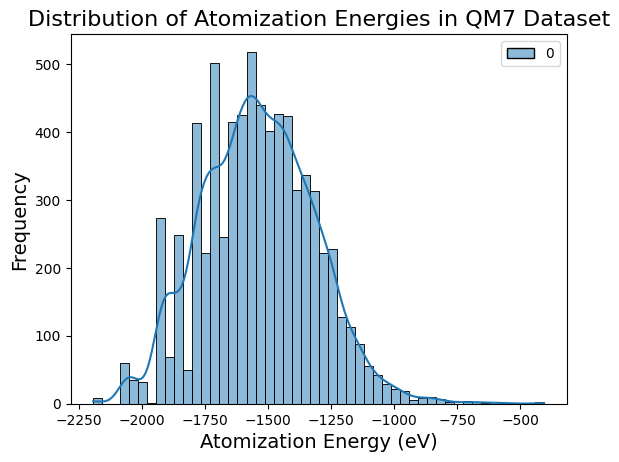

In [17]:
plt.Figure(figsize=(10,6))
sns.histplot(AE, bins=50, kde=True)
plt.title('Distribution of Atomization Energies in QM7 Dataset', fontsize=16)
plt.xlabel('Atomization Energy (eV)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

In [18]:
Data.to_csv('../Dataset/QM7_EDA.csv', index=False)

In [25]:
import requests 
html = requests.get('https://deepchemdata.s3-us-west-1.amazonaws.com')
html.status_code

403

In [26]:
html.text

'<?xml version="1.0" encoding="UTF-8"?>\n<Error><Code>AccessDenied</Code><Message>Access Denied</Message><RequestId>WRVGE3G8DXZ8P7XP</RequestId><HostId>NNZIbSWL9zpl9fb8QIKGc8jVyUvI5vay0f+njWd1Ybvy7edYimGBAqzpdXldOdwK7U7gyUvIMIUwoKn2NNQrxhbdLEHo9Ftj</HostId></Error>'